## **Preprocess**


In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv('/content/annotations_pre_exploration_t2.csv')  
annotators = list(data['name'].unique())
annotators.remove('roni')
annotators.remove('tester')
data=data[data['name'].isin(annotators)]
data=data[data['round_id']>=0]
data=data[data['question_0_This post is:']=='relevant']

for x in data.groupby('example_id').count()[data.groupby('example_id').count()['name']==1].index:
  data=data[data['example_id']!=x]
data

In [ ]:
df = data.copy()
df.columns=['anotator', 'user_id', 'round_id', 'example_id','Q0', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16','Q17']
questions = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16','Q17']
num_q=len(questions)
import itertools
annotators=df['anotator'].unique()
num_annotators=len(annotators)
couples=list(itertools.combinations(annotators, 2))
for i in range(len(couples)):
  couples[i]=list(couples[i])
df


In [ ]:
full_questions=[x.split("_")[2] for x in list(data.columns)[4:]]
full_questions=[x.split("?")[0] for x in full_questions]
full_questions_dict={}
for i in range(1,len(full_questions)):
  full_questions_dict[f'Q{i}']=full_questions[i]

full_questions_dict

{'Q1': 'Total relationship duration',
 'Q2': 'Current relationship status',
 'Q3': "How would you rate the risk level of the woman's relationship based on the information provided in the post",
 'Q4': 'Does she mention avoiding social events or outings with friends or family because of him or maybe making excuses for not going out',
 'Q5': 'Does she frequently feel anxious in her interactions with him, as if she needs to be careful with her words and actions',
 'Q6': 'Does he frequently make her feel guilty',
 'Q7': 'Does he frequently express dissatisfaction with her',
 'Q8': 'Does he try to manipulate her',
 'Q9': "Does she feel she doesn't have option to leave him",
 'Q10': 'Has she mentioned feeling like she has to dress, appear or act a certain way to please him',
 'Q11': 'Does he exhibit a tendency for angry outbursts',
 'Q12': 'Does she ever feel unsafe or threatened by him',
 'Q13': 'Does she mention that he was physically violent to her',
 'Q14': 'Does she mention that he was 

# **Fleiss’s k**

In [ ]:
from statsmodels.stats import inter_rater
import matplotlib.pyplot as plt

def get_Fleiss(df,questions):
  dfs = {}
  pivoted_dfs = {}
  pi = {}

  for j, q in enumerate(questions):
      dfs[q] = df[['anotator', 'example_id', q]]
      pivoted_dfs[q] = df[['anotator', 'example_id', q]].pivot(index='example_id', columns='anotator', values=q)
      pivoted_dfs[q] =pivoted_dfs[q].dropna()      
      table = inter_rater.aggregate_raters(pivoted_dfs[q])
      pi[q] = inter_rater.fleiss_kappa(table[0], method='fleiss')
      if ((table[0].sum(0)/table[0].sum())**2).sum()==1:
        pi[q] = 1.0
  return pi
IAA_Fleiss=get_Fleiss(df,questions)


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/inter_rater.py:264: RuntimeWarning: invalid value encountered in double_scalars
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)
/usr/local/lib/python3.10/dist-packages/statsmodels/stats/inter_rater.py:264: RuntimeWarning: invalid value encountered in double_scalars
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)


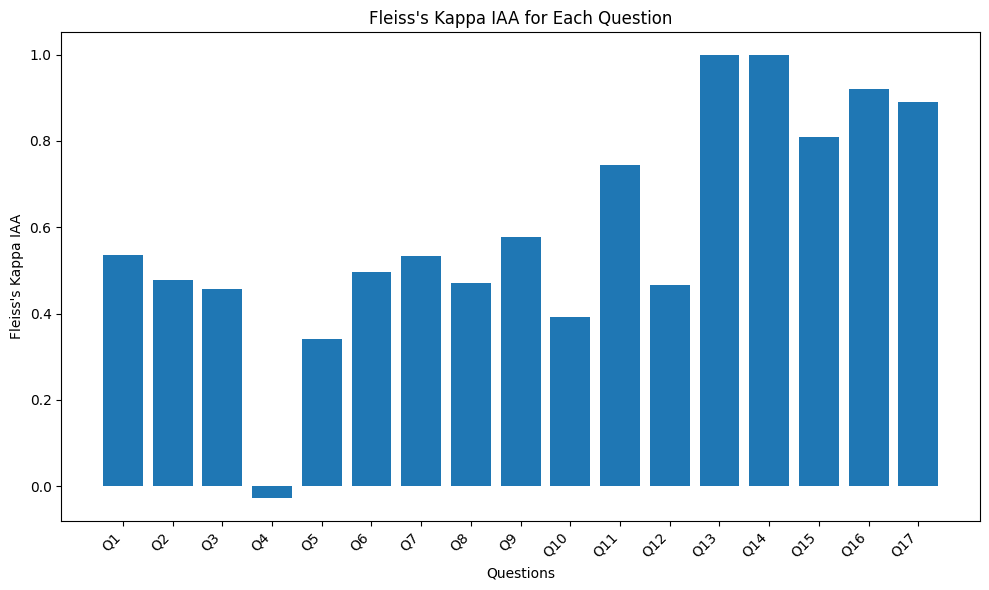

In [ ]:
questions = list(IAA_Fleiss.keys())
kappas = list(IAA_Fleiss.values())
plt.figure(figsize=(10, 6))
plt.bar(questions, kappas)
plt.xlabel('Questions')
plt.ylabel("Fleiss's Kappa IAA")
plt.title("Fleiss's Kappa IAA for Each Question")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

# **Scott's $π$**

In [ ]:
def get_pivoted_pair_df(df,questions):
  dfs={}
  for q in questions:
    nested_df={}
    for pair in couples:
      y=df[df['anotator'].isin(pair)][['anotator','example_id',q]]
      nested_df[(pair[0],pair[1])] = y.pivot(index='example_id', columns='anotator', values=q)
      nested_df[(pair[0],pair[1])] = nested_df[(pair[0],pair[1])].dropna()   
    dfs[q]=nested_df
  return dfs
pivoted_dfs= get_pivoted_pair_df(df,questions)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
def display_heatmap(metric_res,annotators):

  # Set the size of the figure
  plt.figure(figsize=(15, 9))

  # Iterate over each column in the data dictionary
  for i, (col, values) in enumerate(metric_res.items()):
      # Create a matrix of ones with shape (4, 4) to store the heatmap data
      heatmap_data = np.ones((num_annotators, num_annotators))

      # Iterate over each annotator pair and assign the corresponding value to the matrix
      for j, annotator1 in enumerate(annotators):
          for k, annotator2 in enumerate(annotators):
              if j == k:
                  heatmap_data[j][k] = 1.0
              else:
                  heatmap_data[j][k] = values.get((annotator1, annotator2), values.get((annotator2, annotator1), 0))

      # Create a subplot for the current column
      plt.subplot(4, 5, i+1)
      
      # Create the heatmap using seaborn
      ax = sns.heatmap(heatmap_data, cmap='RdYlBu', annot=True, fmt=".2f",
                      linewidths=0.5, xticklabels=annotators, yticklabels=annotators,vmin=-0.1, vmax=1)
      
      # Set the title for the current column
      plt.title(col)
      

  # Adjust the spacing between subplots
  plt.tight_layout()

  # Show the plot
  plt.show()


In [ ]:
from collections import defaultdict
def get_mean_IIA(score_metric,title,ylabel="",with_subjective=False):
  mean_score=defaultdict(int)
  for q,value in score_metric.items():
    if q=="Q1" and not with_subjective:
      continue
    else:
      for pair, score in value.items():
        mean_score[pair]+=score
  for pair,score in mean_score.items():
    mean_score[pair]=score/len(score_metric)
  # Extract the names and values from the defaultdict
  names = [f"{pair[0]} - {pair[1]}" for pair in mean_score.keys()]
  values = list(mean_score.values())

  # Create a bar plot
  plt.bar(names, values)

  # Set the plot title and labels
  plt.title(f"Mean Pairwise {title} IIA")
  plt.xlabel("Annotator Pair")
  plt.ylabel(f"Mean {ylabel} IIA")

  # Rotate the x-axis labels for better readability
  plt.xticks(rotation=45)

  # Display the plot
  plt.show()

def get_mean_IIA_heatmap(score_metric,title,with_subjective=False):
  mean_score=defaultdict(int)
  for q,value in score_metric.items():
    if q=="Q1" and not with_subjective:
      continue
    else:
      for pair, score in value.items():
        mean_score[pair]+=score
  for pair,score in mean_score.items():
    mean_score[pair]=score/len(score_metric)
  heatmap_data = np.ones((5, 5))

  # Iterate over each annotator pair and assign the corresponding value to the matrix
  for j, annotator1 in enumerate(annotators):
    for k, annotator2 in enumerate(annotators):
      if j == k:
        heatmap_data[j][k] = 1.0
      else:
        heatmap_data[j][k] = mean_score.get((annotator1, annotator2), mean_score.get((annotator2, annotator1), 0))
  # Create a heatmap using seaborn
  plt.figure(figsize=(6, 4))
  sns.heatmap(heatmap_data, cmap='RdYlBu', annot=True, fmt=".2f", linewidths=0.5,xticklabels=annotators, yticklabels=annotators,vmin=0, vmax=1)
  plt.title(f"Mean Pairwise {title} IIA")
  plt.xlabel('Annotator')
  plt.ylabel('Annotator')
  plt.show()


In [ ]:
def get_Scott(df):
  Scott_pi={}
  for q in questions:
    nested_df={}
    for pair in couples:
      table=df[q][(pair[0],pair[1])]
      table = inter_rater.aggregate_raters(table)
      nested_df[(pair[0],pair[1])] = inter_rater.fleiss_kappa(table[0], method='fleiss')
      if ((table[0].sum(0)/table[0].sum())**2).sum()==1:
        nested_df[(pair[0],pair[1])] = 1.0
    Scott_pi[q]=nested_df
  return Scott_pi


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/inter_rater.py:264: RuntimeWarning: invalid value encountered in double_scalars
  kappa = (p_mean - p_mean_exp) / (1- p_mean_exp)


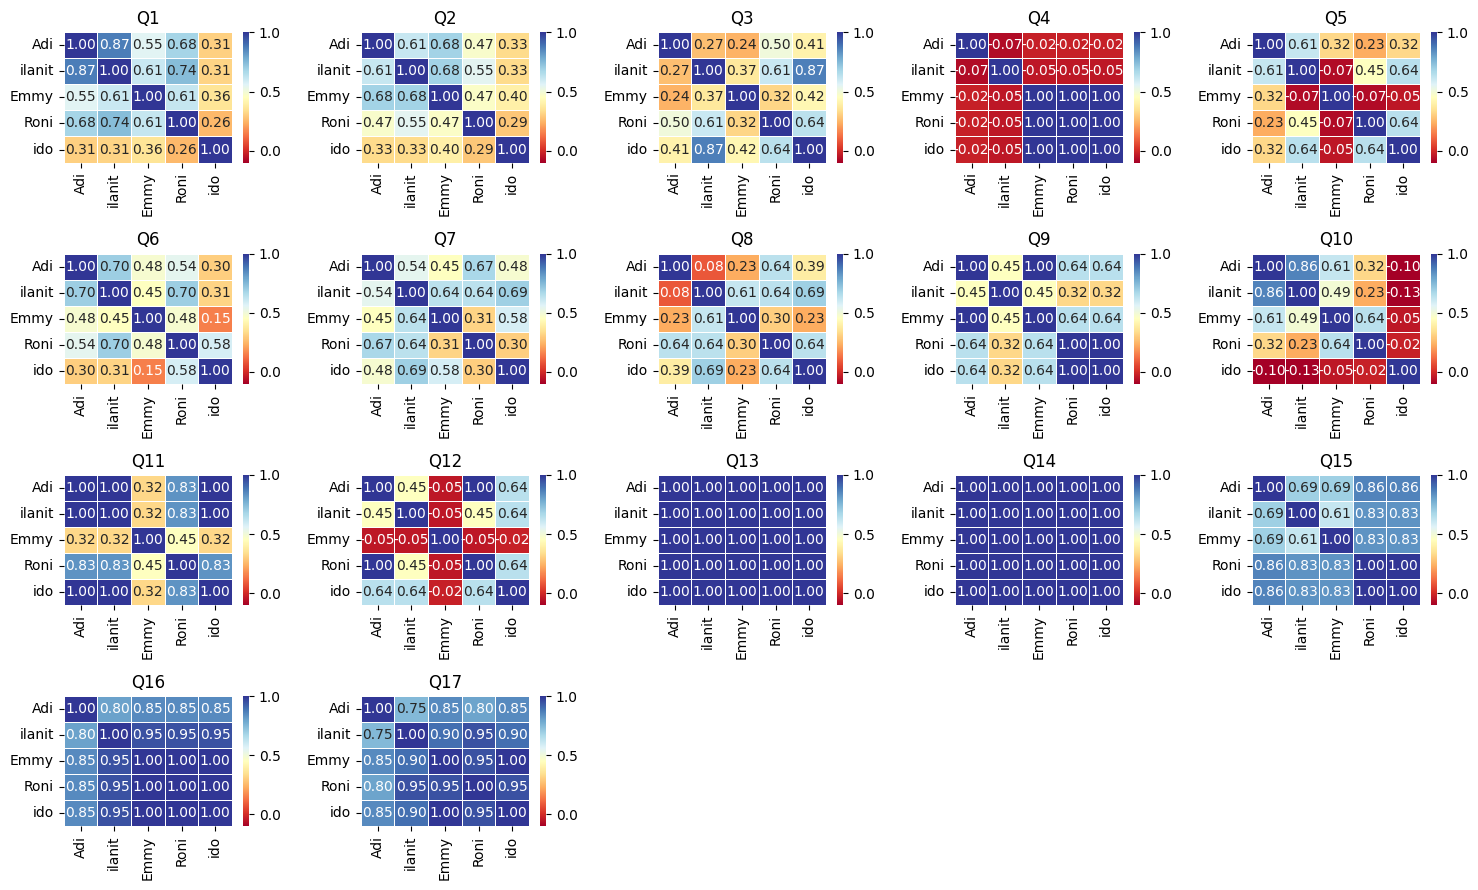

In [ ]:
IAA_Scott=get_Scott(pivoted_dfs)
display_heatmap(IAA_Scott,annotators)

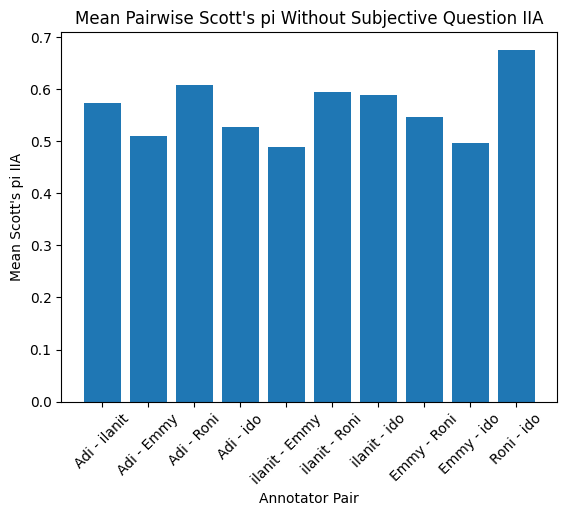

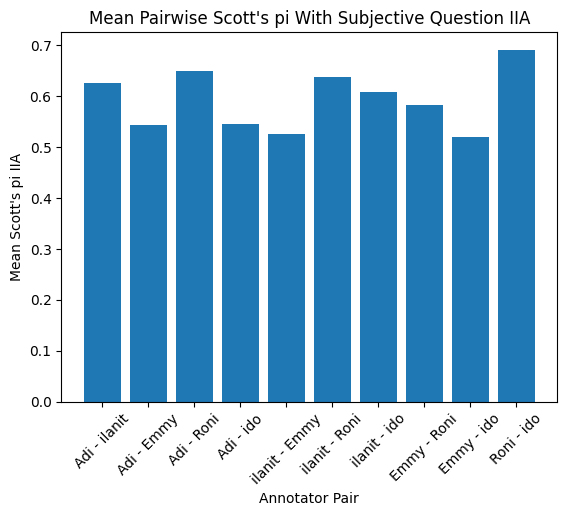

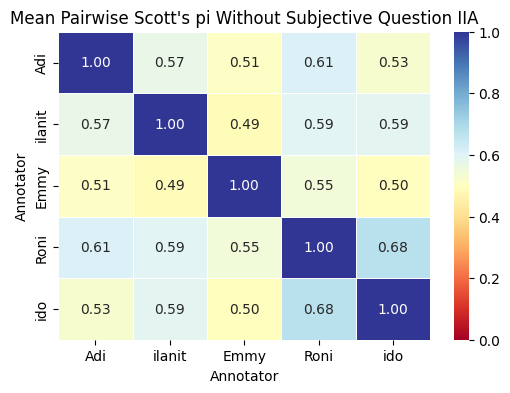

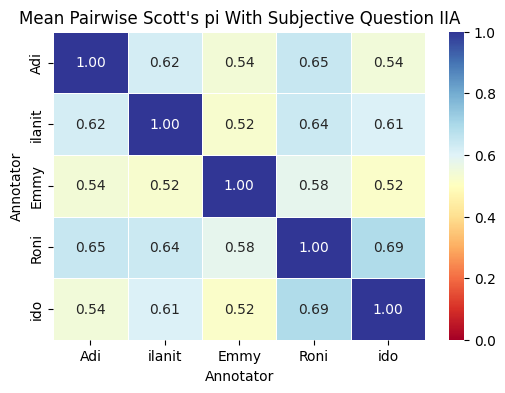

In [ ]:
get_mean_IIA(IAA_Scott,title="Scott's pi Without Subjective Question",ylabel="Scott's pi")
get_mean_IIA(IAA_Scott,title="Scott's pi With Subjective Question",ylabel="Scott's pi",with_subjective=True)
get_mean_IIA_heatmap(IAA_Scott,title="Scott's pi Without Subjective Question")
get_mean_IIA_heatmap(IAA_Scott,title="Scott's pi With Subjective Question",with_subjective=True)


# **Cohen’s k**

In [ ]:
from sklearn.metrics import confusion_matrix

def check(y1, y2):
  confusion = confusion_matrix(y1, y2)
  n_classes = confusion.shape[0]
  sum0 = np.sum(confusion, axis=0)
  sum1 = np.sum(confusion, axis=1)
  expected = np.outer(sum0, sum1) / np.sum(sum0)
  w_mat = np.ones([n_classes, n_classes], dtype=int)
  w_mat.flat[:: n_classes + 1] = 0
  return np.sum(w_mat * expected)




In [ ]:
from sklearn.metrics import cohen_kappa_score
def get_Cohens(df):
  cohens_kappa = {}
  for q in questions:
    nested_df={}
    for pair in couples:
      table=df[q][(pair[0],pair[1])]
      table=table.dropna()
      nested_df[(pair[0],pair[1])] = cohen_kappa_score(table[pair[0]],table[pair[1]])
      if check(table[pair[0]],table[pair[1]])==0:
        nested_df[(pair[0],pair[1])] = 1.0
    cohens_kappa[q]=nested_df
  return cohens_kappa
IAA_Cohen=get_Cohens(pivoted_dfs)

    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:673: RuntimeWarning: invalid value encountered in true_divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:673: RuntimeWarning: invalid value encountered in true_divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:673: RuntimeWarning: invalid value encountered in true_divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:673: RuntimeWarning: invalid value encountered in true_divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:673: RuntimeWarning: invalid value encountered in true_divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/pytho

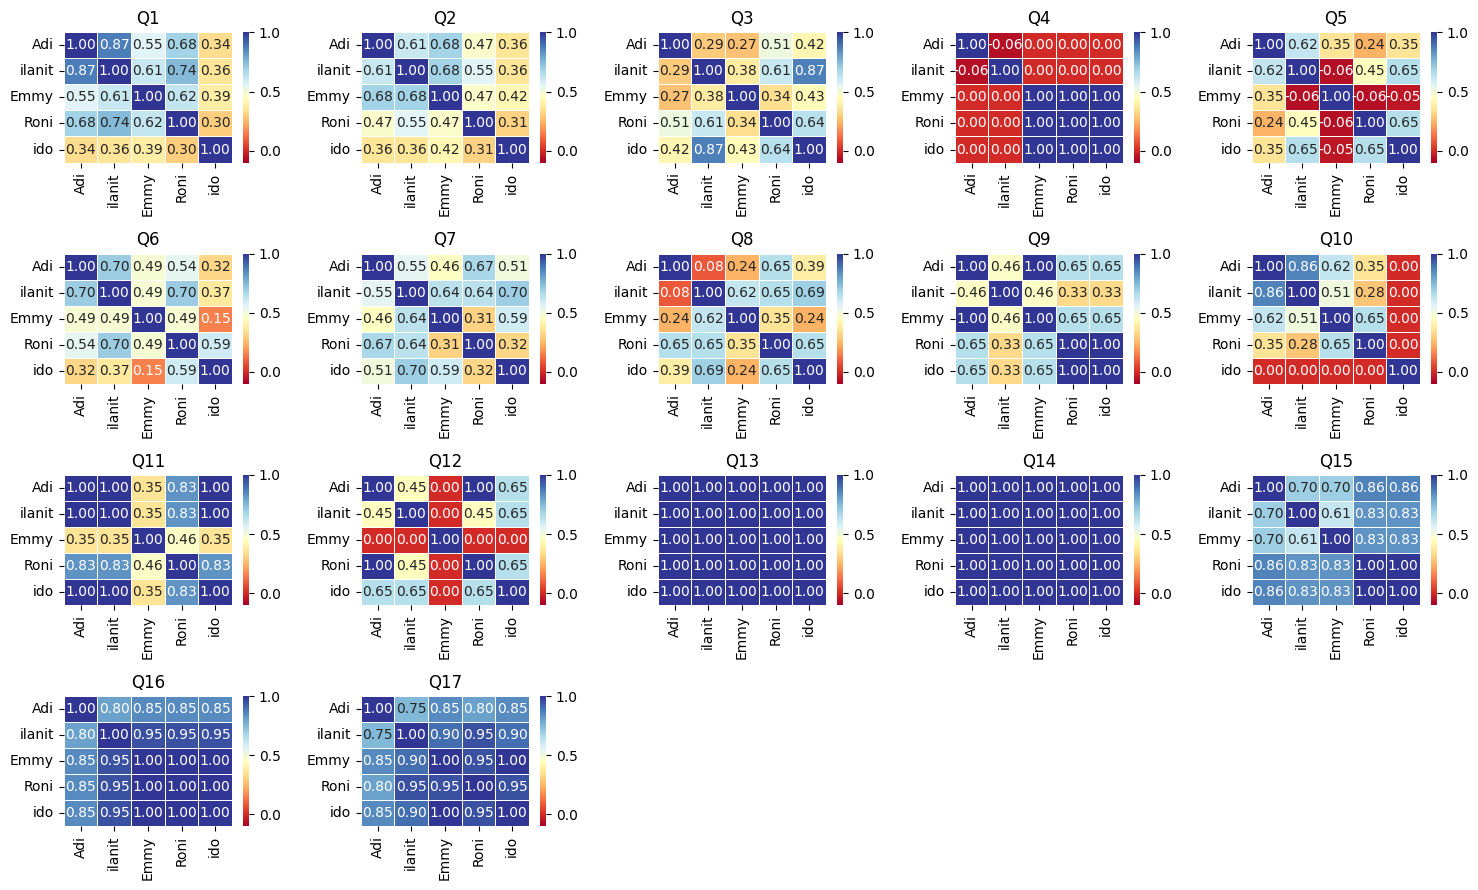

In [ ]:
display_heatmap(IAA_Cohen,annotators)

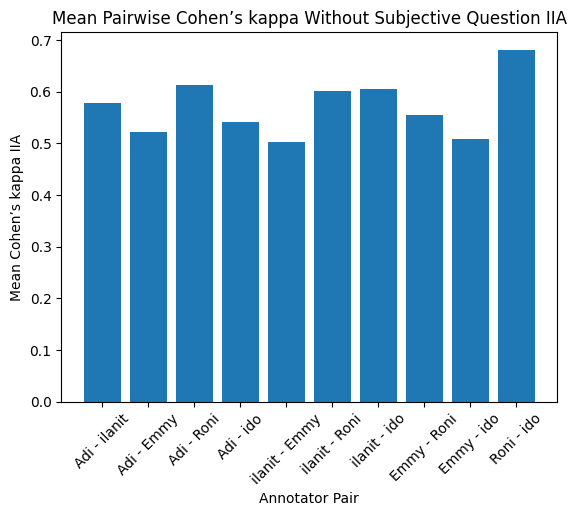

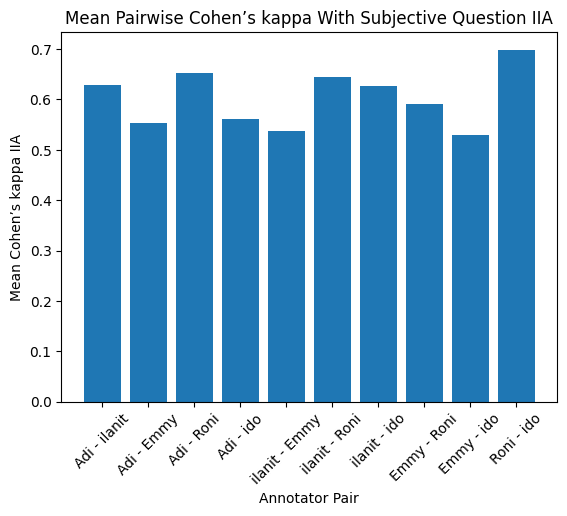

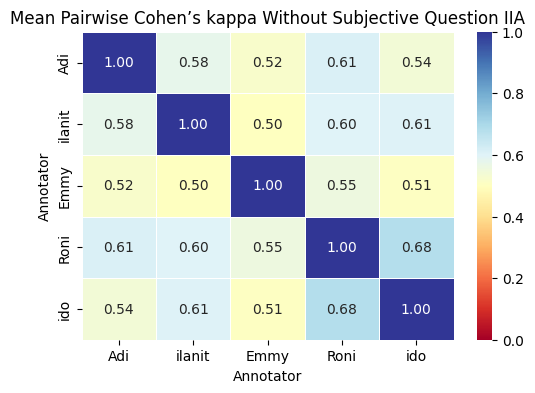

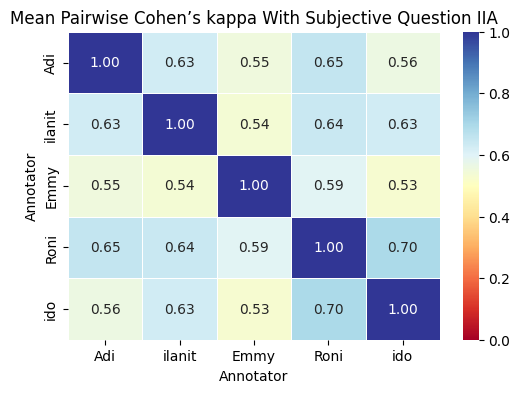

In [ ]:
get_mean_IIA(IAA_Cohen,title="Cohen’s kappa Without Subjective Question",ylabel="Cohen’s kappa")
get_mean_IIA(IAA_Cohen,title="Cohen’s kappa With Subjective Question",ylabel="Cohen’s kappa", with_subjective=True)
get_mean_IIA_heatmap(IAA_Cohen,title="Cohen’s kappa Without Subjective Question")
get_mean_IIA_heatmap(IAA_Cohen,title="Cohen’s kappa With Subjective Question", with_subjective=True)

# **Distribution of questions**

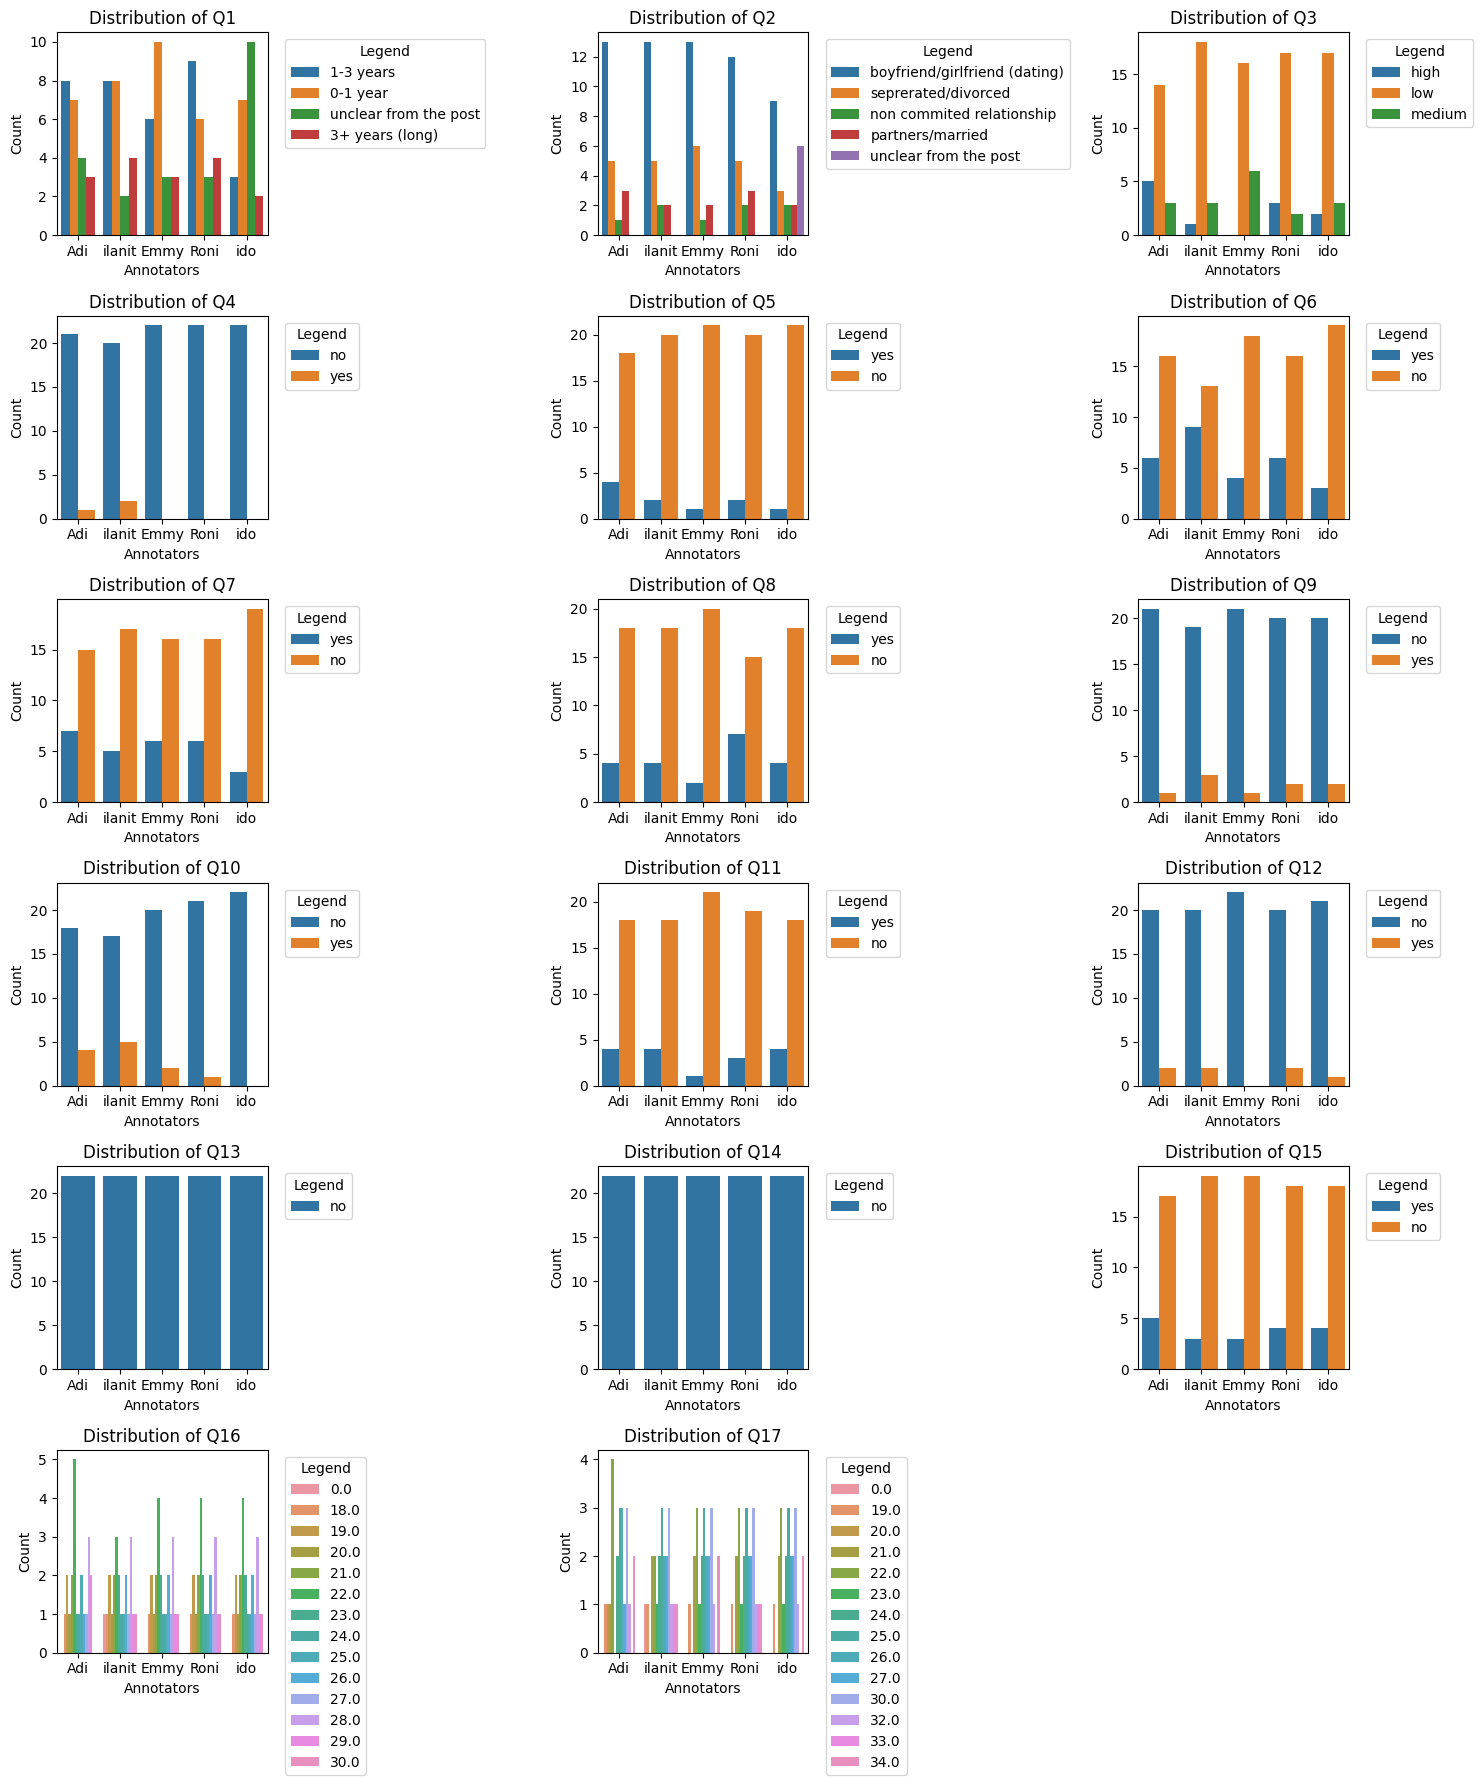

In [ ]:
# Calculate the number of rows and columns for subplots based on the number of questions
num_rows = int(np.ceil(len(questions) / 3))
num_cols = min(len(questions), 3)

# Set the size of the figure
plt.figure(figsize=(15, 3 * num_rows))

# Iterate over each question
for i, q in enumerate(questions):
    # Create a DataFrame for the current question
    temp = df[['anotator', 'example_id', q]]

    # Create a subplot for the current question
    ax = plt.subplot(num_rows, num_cols, i + 1)

    # Plot the distribution using seaborn
    sns.countplot(data=temp, x='anotator', hue=q, order=annotators)

    # Set the title and labels
    plt.title(f'Distribution of {q}')
    plt.xlabel('Annotators')
    plt.ylabel('Count')
    ax.legend_.remove()

    # Add a common legend outside the subplots
    plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')



# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


# **Correlations**

### **Kendall's τ Correlation For The Subjective Risk Level Question**

<ipython-input-83-54ceda4f1d9b>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q3['Q3'] = Q3['Q3'].replace(mapping)


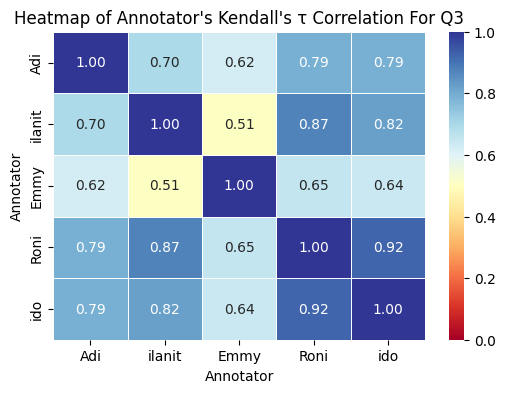

In [ ]:
import scipy.stats as stats
Q3 = df[['anotator','example_id',"Q3"]]
mapping = {'low': 1, 'medium': 2, 'high': 3}

# Replace the values in the 'Q3' column
Q3['Q3'] = Q3['Q3'].replace(mapping)

pivoted_df = Q3.pivot(index='example_id', columns='anotator', values="Q3")

tau_corr={}
for pair in couples:
  x=pivoted_df[pair[0]]
  y=pivoted_df[pair[1]]
  tau, p_value = stats.kendalltau(x, y)
  tau_corr[(pair[0],pair[1])]=tau


heatmap_data = np.ones((5, 5))

# Iterate over each annotator pair and assign the corresponding value to the matrix
for j, annotator1 in enumerate(annotators):
  for k, annotator2 in enumerate(annotators):
    if j == k:
      heatmap_data[j][k] = 1.0
    else:
      heatmap_data[j][k] = tau_corr.get((annotator1, annotator2), tau_corr.get((annotator2, annotator1), 0))
# Create a heatmap using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data, cmap='RdYlBu', annot=True, fmt=".2f", linewidths=0.5,xticklabels=annotators, yticklabels=annotators,vmin=0, vmax=1)
plt.title("Heatmap of Annotator's Kendall's τ Correlation For Q3")
plt.xlabel('Annotator')
plt.ylabel('Annotator')
plt.show()

In [ ]:
!pip install dython

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 42.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.4
    Uninstalling numpy-1.22.4:
      Successfully uninstalled numpy-1.22.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 1.24.3 which is incompatible.
tensorflow 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 1.24.3 which is incompatible.


In [ ]:
import pandas as pd
from dython.nominal import associations

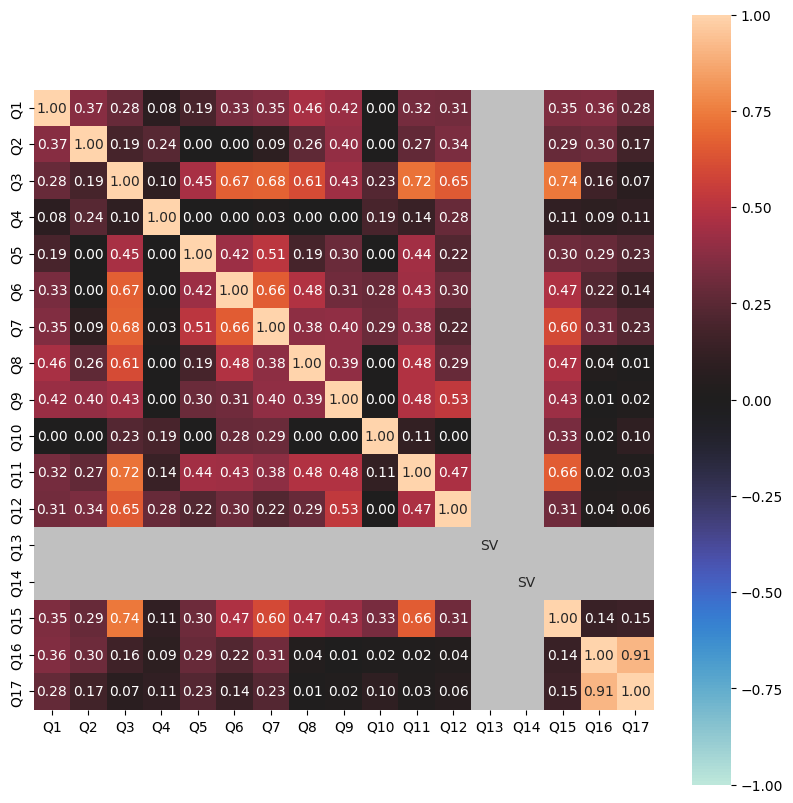

<ipython-input-29-89b41e9824ae>:3: FutureWarning: this method is deprecated in favour of `Styler.format(precision=..)`
  df_complete_corr.dropna(axis=1, how='all').dropna(axis=0, how='all').style.background_gradient(cmap='coolwarm', axis=None).set_precision(2)


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17
Q1,1.00,0.37,0.28,0.08,0.19,0.33,0.35,0.46,0.42,0.00,0.32,0.31,0.00,0.00,0.35,0.36,0.28
Q2,0.37,1.00,0.19,0.24,0.00,0.00,0.09,0.26,0.40,0.00,0.27,0.34,0.00,0.00,0.29,0.30,0.17
Q3,0.28,0.19,1.00,0.10,0.45,0.67,0.68,0.61,0.43,0.23,0.72,0.65,0.00,0.00,0.74,0.16,0.07
Q4,0.08,0.24,0.10,1.00,0.00,0.00,0.03,0.00,0.00,0.19,0.14,0.28,0.00,0.00,0.11,0.09,0.11
Q5,0.19,0.00,0.45,0.00,1.00,0.42,0.51,0.19,0.30,0.00,0.44,0.22,0.00,0.00,0.30,0.29,0.23
Q6,0.33,0.00,0.67,0.00,0.42,1.00,0.66,0.48,0.31,0.28,0.43,0.30,0.00,0.00,0.47,0.22,0.14
Q7,0.35,0.09,0.68,0.03,0.51,0.66,1.00,0.38,0.40,0.29,0.38,0.22,0.00,0.00,0.60,0.31,0.23
Q8,0.46,0.26,0.61,0.00,0.19,0.48,0.38,1.00,0.39,0.00,0.48,0.29,0.00,0.00,0.47,0.04,0.01
Q9,0.42,0.40,0.43,0.00,0.30,0.31,0.40,0.39,1.00,0.00,0.48,0.53,0.00,0.00,0.43,0.01,0.02
Q10,0.00,0.00,0.23,0.19,0.00,0.28,0.29,0.00,0.00,1.00,0.11,0.00,0.00,0.00,0.33,0.02,0.10


In [ ]:
complete_correlation= associations(df[questions], filename= 'complete_correlation.png', figsize=(10,10))
df_complete_corr=complete_correlation['corr']
df_complete_corr.dropna(axis=1, how='all').dropna(axis=0, how='all').style.background_gradient(cmap='coolwarm', axis=None).set_precision(2)

columns 13 and 14 show 0 correlation with everything because all of us answered the same in those questions, it means that there is no variability in the responses for those columns. Since there is no variability, the correlation coefficient will be 0 because there is no linear relationship to measure.